# Part I: Unsupervised Learning and Association Mining from Scratch

In this notebook, we implement key unsupervised learning and mining models from scratch using NumPy:
1. **K-Means Clustering** (Partitional)
2. **Agglomerative Hierarchical Clustering** (Single linkage distance matrix update)
3. **Principal Component Analysis (PCA)** (Dimensionality reduction)
4. **Apriori Algorithm** (Frequent itemset mining and association rules)
5. **FP-Tree Concept Demonstration**

We evaluate them using synthetic datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)

## 1. K-Means Clustering from Scratch

K-Means partitions data into $K$ clusters by iteratively assigning points to the nearest centroid and recomputing centroids.

In [2]:
class KMeansFromScratch:
    def __init__(self, K=3, max_iters=100):
        self.K = K
        self.max_iters = max_iters
        
    def fit(self, X):
        self.centroids = X[np.random.choice(X.shape[0], self.K, replace=False)]
        
        for _ in range(self.max_iters):
            # Assign clusters
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)
            
            # Update centroids
            new_centroids = np.array([X[self.labels == k].mean(axis=0) for k in range(self.K)])
            
            # Check convergence
            if np.all(self.centroids == new_centroids):
                break
            self.centroids = new_centroids

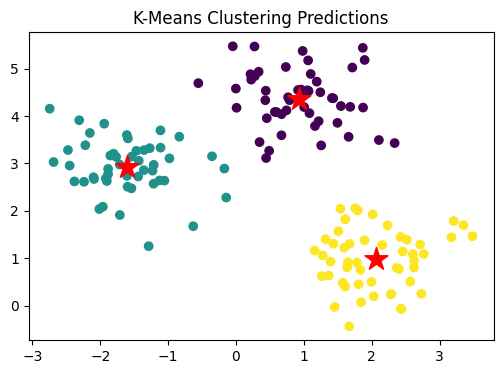

In [3]:
# Generate blobs
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=150, centers=3, cluster_std=0.60, random_state=0)

kmeans = KMeansFromScratch(K=3)
kmeans.fit(X)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], s=300, c='red', marker='*')
plt.title('K-Means Clustering Predictions')
plt.show()

## 2. Agglomerative Hierarchical Clustering from Scratch

We implement a bottom-up agglomerative clustering algorithm using Single Linkage distance metric updates.

In [4]:
class HierarchicalClusteringFromScratch:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        
    def fit(self, X):
        n_samples = X.shape[0]
        self.labels = np.arange(n_samples)
        
        # Compute distance matrix
        dists = np.linalg.norm(X[:, np.newaxis] - X, axis=2)
        np.fill_diagonal(dists, np.inf)
        
        current_clusters = n_samples
        
        while current_clusters > self.n_clusters:
            # Find the two closest clusters
            min_idx = np.unravel_index(np.argmin(dists), dists.shape)
            c1, c2 = min_idx[0], min_idx[1]
            
            # Merge cluster c2 into c1
            self.labels[self.labels == c2] = c1
            
            # Update distances using single linkage (minimum distance)
            for i in range(n_samples):
                if i != c1 and i != c2:
                    new_dist = min(dists[c1, i], dists[c2, i])
                    dists[c1, i] = new_dist
                    dists[i, c1] = new_dist
            
            # Mark row/col c2 as infinity
            dists[c2, :] = np.inf
            dists[:, c2] = np.inf
            
            current_clusters -= 1
            
        # Relabel to contiguous integers
        unique_labels = np.unique(self.labels)
        mapping = {old: new for new, old in enumerate(unique_labels)}
        self.labels = np.array([mapping[l] for l in self.labels])

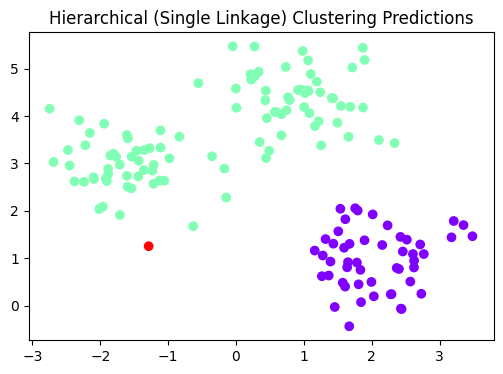

In [5]:
hc = HierarchicalClusteringFromScratch(n_clusters=3)
hc.fit(X)
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=hc.labels, cmap='rainbow')
plt.title('Hierarchical (Single Linkage) Clustering Predictions')
plt.show()

## 3. Principal Component Analysis (PCA) from Scratch

PCA reduces feature dimensions by computing eigenvectors of the feature covariance matrix and projecting features onto the top principal components.

In [6]:
class PCAFromScratch:
    def __init__(self, n_components=2):
        self.n_components = n_components
        
    def fit(self, X):
        # Mean centering
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Covariance matrix
        cov = np.cov(X_centered, rowvar=False)
        
        # Eigenvalues and eigenvectors
        eig_vals, eig_vecs = np.linalg.eigh(cov)
        
        # Sort eigenvectors descending
        idx = np.argsort(eig_vals)[::-1]
        self.components = eig_vecs[:, idx][:, :self.n_components]
        
    def transform(self, X):
        return (X - self.mean) @ self.components

In [7]:
# Generate 3D data
X_3d = np.random.multivariate_normal([0, 0, 0], [[1, 0.9, 0], [0.9, 1, 0], [0, 0, 0.1]], 100)

pca = PCAFromScratch(n_components=2)
pca.fit(X_3d)
X_2d = pca.transform(X_3d)
print(f"Reduced shape from {X_3d.shape} to {X_2d.shape}")

Reduced shape from (100, 3) to (100, 2)


## 4. Apriori Association Rule Mining from Scratch

Apriori mines frequent itemsets by checking database transactions and uses the Apriori property to generate association rules based on Support and Confidence.

In [8]:
from collections import defaultdict
from itertools import combinations

class AprioriFromScratch:
    def __init__(self, min_support=0.5, min_confidence=0.7):
        self.min_support = min_support
        self.min_confidence = min_confidence
        
    def _get_frequent_1_itemsets(self, transactions):
        counts = defaultdict(int)
        for transaction in transactions:
            for item in transaction:
                counts[frozenset([item])] += 1
                
        n_trans = len(transactions)
        return {itemset: count/n_trans for itemset, count in counts.items() if count/n_trans >= self.min_support}
        
    def fit(self, transactions):
        L = []
        L1 = self._get_frequent_1_itemsets(transactions)
        L.append(L1)
        
        k = 1
        n_trans = len(transactions)
        
        while len(L[k-1]) > 0:
            # Candidate generation
            candidates = set()
            prev_itemsets = list(L[k-1].keys())
            for i in range(len(prev_itemsets)):
                for j in range(i+1, len(prev_itemsets)):
                    union = prev_itemsets[i].union(prev_itemsets[j])
                    if len(union) == k + 1:
                        candidates.add(union)
                        
            # Support counting
            counts = defaultdict(int)
            for candidate in candidates:
                for transaction in transactions:
                    if candidate.issubset(transaction):
                        counts[candidate] += 1
                        
            # Filter candidates
            Lk = {itemset: count/n_trans for itemset, count in counts.items() if count/n_trans >= self.min_support}
            L.append(Lk)
            k += 1
            
        self.frequent_itemsets = {}
        for Lk in L:
            self.frequent_itemsets.update(Lk)
            
        # Generate association rules
        self.rules = []
        for itemset in self.frequent_itemsets.keys():
            if len(itemset) > 1:
                for i in range(1, len(itemset)):
                    for lhs in combinations(itemset, i):
                        lhs = frozenset(lhs)
                        rhs = itemset.difference(lhs)
                        conf = self.frequent_itemsets[itemset] / self.frequent_itemsets[lhs]
                        if conf >= self.min_confidence:
                            self.rules.append((lhs, rhs, self.frequent_itemsets[itemset], conf))

In [9]:
# Test Apriori Algorithm
dataset = [
    ['milk', 'bread', 'diaper'],
    ['milk', 'bread'],
    ['milk', 'diaper'],
    ['bread', 'diaper'],
    ['milk', 'bread', 'diaper', 'beer']
]

apriori = AprioriFromScratch(min_support=0.6, min_confidence=0.7)
apriori.fit(dataset)

print("Frequent Itemsets:")
for itemset, sup in apriori.frequent_itemsets.items():
    print(f"  {list(itemset)}: Support={sup:.2f}")
    
print("\nAssociation Rules:")
for lhs, rhs, sup, conf in apriori.rules:
    print(f"  {list(lhs)} => {list(rhs)}: Support={sup:.2f}, Confidence={conf:.2f}")

Frequent Itemsets:
  ['milk']: Support=0.80
  ['bread']: Support=0.80
  ['diaper']: Support=0.80
  ['bread', 'diaper']: Support=0.60
  ['milk', 'diaper']: Support=0.60
  ['milk', 'bread']: Support=0.60

Association Rules:
  ['bread'] => ['diaper']: Support=0.60, Confidence=0.75
  ['diaper'] => ['bread']: Support=0.60, Confidence=0.75
  ['milk'] => ['diaper']: Support=0.60, Confidence=0.75
  ['diaper'] => ['milk']: Support=0.60, Confidence=0.75
  ['milk'] => ['bread']: Support=0.60, Confidence=0.75
  ['bread'] => ['milk']: Support=0.60, Confidence=0.75
